## Preparing the dataset for modelling (NOT READY YET)

Best results (pearson correlation) for window size: variable/size/p correlation

NDVI class 1      /  15  /  -0.72

NDVI class 0.5    /  6   /   0.02

NDWI class 1      /  8   /  -0.1

Volumen veg       /  7   /  -0.61

volumen edif      /  9   /   0.42

area edif         /  8   /   0.50

elev mean         /  1   /  -0.15

slope mean        /  100 /  -0.65

northness         /  60  /  -0.28

eastness          /  11  /  -0.17

In [1]:
import os
import numpy as np
import rasterio
from rasterio import mask
import geopandas as gpd
import matplotlib.pyplot as plt


In [9]:
# variables
lst_clipped_path = '../../datos-notebooks/0.LST/LST_clipped_celsius.tif'
ndvi_1 = '../../datos-notebooks/1.land-cover/moving-windows/ndvi/Class_1_window15.tif'
ndwi_1 = '../../datos-notebooks/1.land-cover/moving-windows/ndwi/Class_1_window8.tif'
veg_vol = '../../datos-notebooks/2.objects-height/moving-windows/tree-volume/trees_window7.tif'
built_vol = '../../datos-notebooks/2.objects-height/moving-windows/building-volume/buildings_window9.tif'
built_area = '../../datos-notebooks/2.objects-height/moving-windows/building-area/building_area_window8.tif'
mean_elev = '../../datos-notebooks/3.topography/dtm_30m/elev_mean/elev_mean_win70.tif'
mean_slope = '../../datos-notebooks/3.topography/dtm_30m/slope_mean/slope_mean_win10.tif'
northness = '../../datos-notebooks/3.topography/dtm_30m/northness/northness_win200.tif'

output_dir = '../../datos-notebooks/4.LST-prediction/'
os.makedirs(output_dir, exist_ok=True)

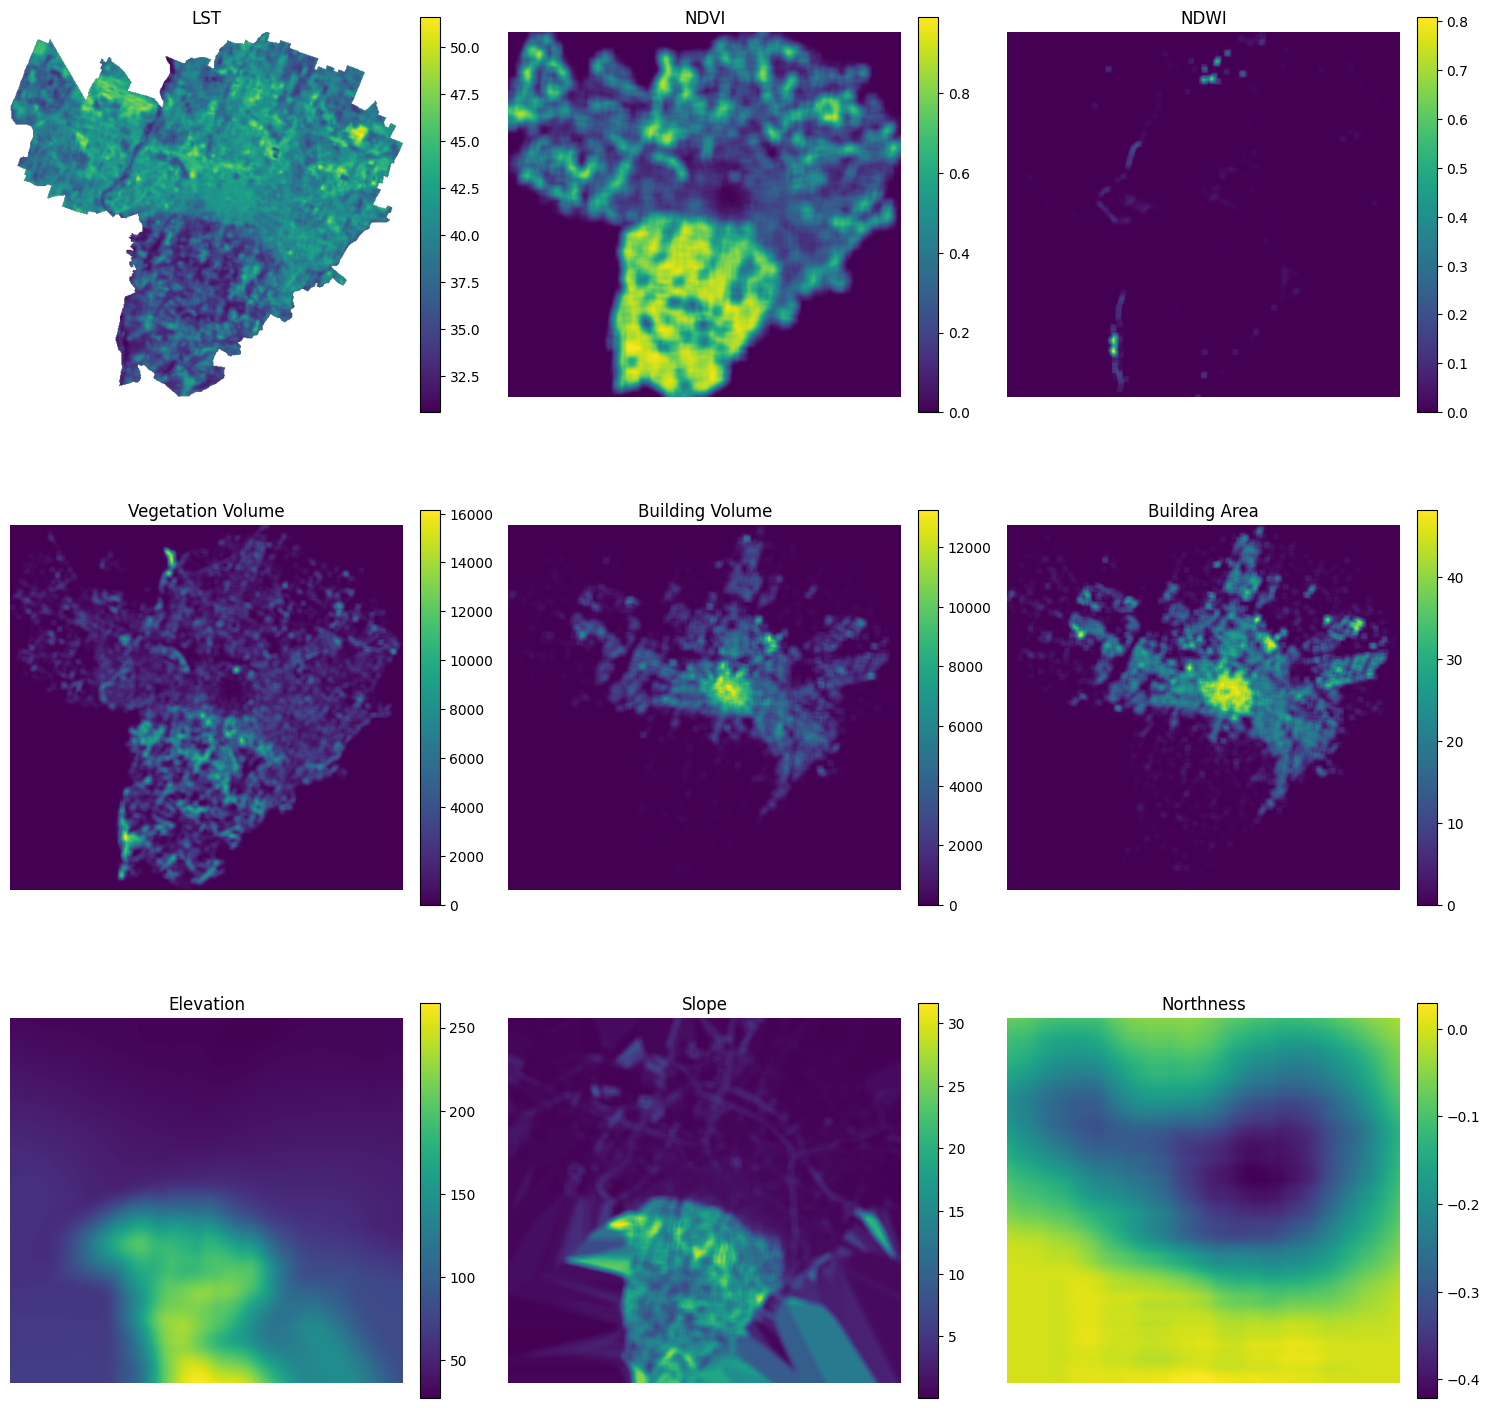

In [10]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np

# Diccionario de variables
rasters = {
    "LST": lst_clipped_path,
    "NDVI": ndvi_1,
    "NDWI": ndwi_1,
    "Vegetation Volume": veg_vol,
    "Building Volume": built_vol,
    "Building Area": built_area,
    "Elevation": mean_elev,
    "Slope": mean_slope,
    "Northness": northness
}

n_vars = len(rasters)
cols = 3
rows = (n_vars + cols - 1) // cols  # ceil division

fig, axes = plt.subplots(rows, cols, figsize=(15, 5*rows))

for ax, (name, path) in zip(axes.flat, rasters.items()):
    with rasterio.open(path) as src:
        data = src.read(1)
        img = ax.imshow(data, cmap='viridis')
        ax.set_title(name)
        ax.axis('off')
        fig.colorbar(img, ax=ax, fraction=0.046, pad=0.04)

# Hide any unused subplots
for ax in axes.flat[n_vars:]:
    ax.axis('off')

plt.tight_layout()
plt.show()


### stratified sampling of LST

In [11]:
import rasterio
import numpy as np
import pandas as pd

# Dictionary of rasters
rasters = {
    "LST": lst_clipped_path,
    "NDVI": ndvi_1,
    "NDWI": ndwi_1,
    "VegetationVolume": veg_vol,
    "BuildingVolume": built_vol,
    "BuildingArea": built_area,
    "Elevation": mean_elev,
    "Slope": mean_slope,
    "Northness": northness
}

# Read and flatten
data_arrays = {}
for name, path in rasters.items():
    with rasterio.open(path) as src:
        arr = src.read(1)
        data_arrays[name] = arr.flatten()

df = pd.DataFrame(data_arrays)

# Drop rows with NaN
df = df.dropna()

# Create LST bins for stratification (5 bins)
n_bins = 5
df['LST_bin'] = pd.qcut(df['LST'], n_bins, labels=False)

# Stratified sampling: 5% of each bin
sample_fraction = 0.05
df_sampled = df.groupby('LST_bin', group_keys=False).apply(
    lambda x: x.sample(frac=sample_fraction, random_state=42)
)

# Drop bin column
df_sampled = df_sampled.drop(columns=['LST_bin']).reset_index(drop=True)

print(df_sampled.head())
print("Sampled dataset shape:", df_sampled.shape)

# Split features and target
X = df_sampled.drop(columns=['LST'])
y = df_sampled['LST']


         LST      NDVI      NDWI  VegetationVolume  BuildingVolume  \
0  33.444649  0.911935  0.000000       6135.938965    1.425076e+02   
1  34.654629  0.514596  0.000000        585.346924   -3.947459e-14   
2  36.144882  0.223039  0.000000         60.392857    3.031649e-13   
3  34.046219  0.636872  0.000404       6246.423340    5.222095e+02   
4  33.352360  0.827930  0.000000       5971.224609    4.364102e+01   

   BuildingArea   Elevation      Slope  Northness  
0      1.577222  182.073395  15.667623  -0.178034  
1      0.000025   39.934498   0.418152  -0.237256  
2      0.000000   31.440973   0.289772  -0.171305  
3      3.593055  105.155632  13.884149  -0.314476  
4      0.941667  200.849625  15.376139  -0.092701  
Sampled dataset shape: (7823, 9)


C:\Users\guada\AppData\Local\Temp\ipykernel_25792\3230927108.py:36: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_sampled = df.groupby('LST_bin', group_keys=False).apply(


In [12]:
# Number of rows and columns
print(df_sampled.shape)  
# Output: (number_of_pixels, number_of_variables)

# Number of pixels (rows)
print(len(df_sampled))

# Number of features (columns) excluding target
print(X.shape[1])

# Quick info about dataset
print(df_sampled.info())


(7823, 9)
7823
8
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7823 entries, 0 to 7822
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   LST               7823 non-null   float32
 1   NDVI              7823 non-null   float32
 2   NDWI              7823 non-null   float32
 3   VegetationVolume  7823 non-null   float32
 4   BuildingVolume    7823 non-null   float32
 5   BuildingArea      7823 non-null   float32
 6   Elevation         7823 non-null   float32
 7   Slope             7823 non-null   float32
 8   Northness         7823 non-null   float32
dtypes: float32(9)
memory usage: 275.2 KB
None


In [13]:
import pandas as pd

# Recreate bins for the sampled dataset
n_bins = 5
df_sampled['LST_bin'] = pd.qcut(df_sampled['LST'], n_bins, labels=False)

# Show min and max LST in each bin
for b in range(n_bins):
    values_in_bin = df_sampled[df_sampled['LST_bin'] == b]['LST']
    print(f"Bin {b}: min = {values_in_bin.min():.2f}, max = {values_in_bin.max():.2f}, count = {len(values_in_bin)}")



Bin 0: min = 30.96, max = 36.29, count = 1566
Bin 1: min = 36.29, max = 38.56, count = 1565
Bin 2: min = 38.57, max = 40.21, count = 1563
Bin 3: min = 40.22, max = 41.74, count = 1566
Bin 4: min = 41.74, max = 50.57, count = 1563


In [14]:
!pip install seaborn


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: C:\Users\guada\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


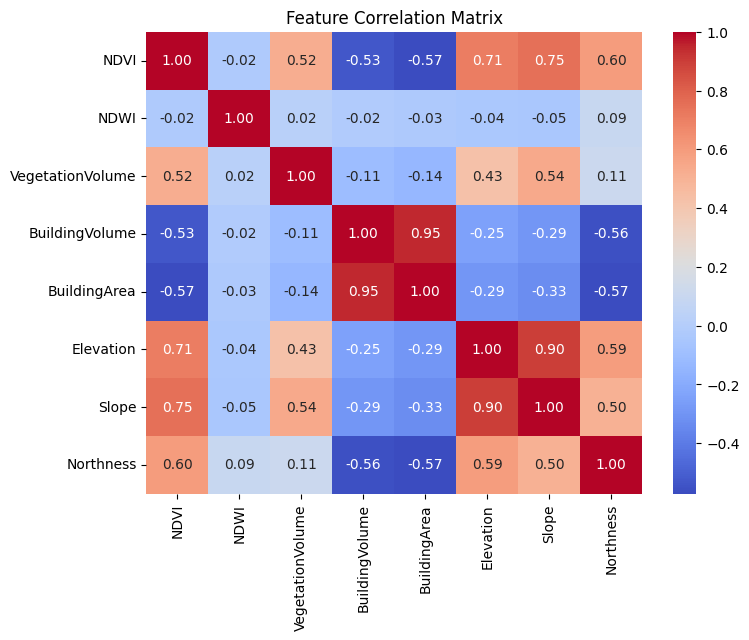

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute correlation matrix (only features)
corr_matrix = X.corr()

# Display heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()
